<a href="https://colab.research.google.com/github/Rupasri-555/ML-LAB/blob/main/TASK_8(IN_LAB).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

# Prevent copy warnings using an explicit copy
X_pima = pima_df[pima_cols[:-1]].copy()
y_pima = pima_df['Outcome']

# Mark invalid zeros as NaN placeholders for imputation
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_pima[cols_to_impute] = X_pima[cols_to_impute].replace(0, np.nan)

# Impute and standardize
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_pima)

scaler = StandardScaler()
X_pima_scaled = scaler.fit_transform(X_imputed)

# Stratified train-test split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima_scaled, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

print("Preprocessed Pima dataset shapes:")
print(f"  Training set features: {X_train_p.shape} | Test set features: {X_test_p.shape}")


Preprocessed Pima dataset shapes:
  Training set features: (614, 8) | Test set features: (154, 8)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Design baseline sequential model
ann_pima = Sequential([
    # Input layer + Hidden layer 1: 16 neurons with ReLU activation
    Dense(16, activation='relu', input_shape=(8,)),
    # Hidden layer 2: 8 neurons with ReLU activation
    Dense(8, activation='relu'),
    # Output layer: 1 neuron with Sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

print("Sequential ANN Architecture established:")
ann_pima.summary()


Sequential ANN Architecture established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Compile the neural network model
ann_pima.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Neural network model compiled successfully.")


Neural network model compiled successfully.


In [4]:
# Fit model and collect training metrics
history_pima = ann_pima.fit(
    X_train_p,
    y_train_p,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6069 - loss: 0.6803 - val_accuracy: 0.6504 - val_loss: 0.6782
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6843 - loss: 0.6425 - val_accuracy: 0.7154 - val_loss: 0.6348
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7251 - loss: 0.6058 - val_accuracy: 0.7236 - val_loss: 0.5916
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7373 - loss: 0.5668 - val_accuracy: 0.7480 - val_loss: 0.5474
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7536 - loss: 0.5281 - val_accuracy: 0.7805 - val_loss: 0.5118
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7576 - loss: 0.5002 - val_accuracy: 0.7642 - val_loss: 0.4800
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7658 - loss: 0.4804 - val_accuracy: 0.7886 - val_loss: 0.4626
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7780 - loss: 0.4672 - val_accuracy: 0.7886 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
ANN Holdout Test Accuracy: 72.08%

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.77      0.81      0.79       100
    Diabetes       0.61      0.56      0.58        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.69       154
weighted avg       0.72      0.72      0.72       154



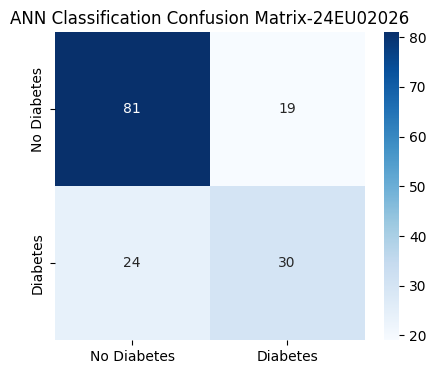

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predict target probabilities
y_pred_probs = ann_pima.predict(X_test_p)
# Threshold probabilities to binary classes (0 or 1)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

test_acc = accuracy_score(y_test_p, y_pred_classes)
print(f"ANN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test_p, y_pred_classes, target_names=['No Diabetes', 'Diabetes']))

# Plot confusion matrix
cm_pima = confusion_matrix(y_test_p, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("ANN Classification Confusion Matrix-24EU02026")
plt.show()


In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Design regularized sequential network
ann_sonar = Sequential([
    # Input layer + Dense hidden layer 1
    Dense(64, activation='relu', input_shape=(60,)),
    Dropout(0.3), # Apply 30% dropout rate to mitigate co-adaptation
    # Dense hidden layer 2
    Dense(32, activation='relu'),
    Dropout(0.3), # Apply 30% dropout rate
    # Binary sigmoid output node
    Dense(1, activation='sigmoid')
])

print("Regularized Sonar ANN Architecture established:")
ann_sonar.summary()


Regularized Sonar ANN Architecture established:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the model
ann_sonar.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fit model and collect training metrics
history_sonar = ann_sonar.fit(
    X_train_s,
    y_train_s,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")


Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5259 - loss: 0.7668 - val_accuracy: 0.5517 - val_loss: 0.6613
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5431 - loss: 0.6980 - val_accuracy: 0.7586 - val_loss: 0.5909
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6638 - loss: 0.5928 - val_accuracy: 0.7931 - val_loss: 0.5483
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7241 - loss: 0.5690 - val_accuracy: 0.7931 - val_loss: 0.5156
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7414 - loss: 0.5827 - val_accuracy: 0.8276 - val_loss: 0.4941
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7328 - loss: 0.5475 - val_accuracy: 0.7931 - val_loss: 0.4755
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7586 - loss: 0.4934 - val_accuracy: 0.8276 - val_loss: 0.4582
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8190 - loss: 0.4860 - val_accuracy: 0.8621 - val_loss: 0.4422


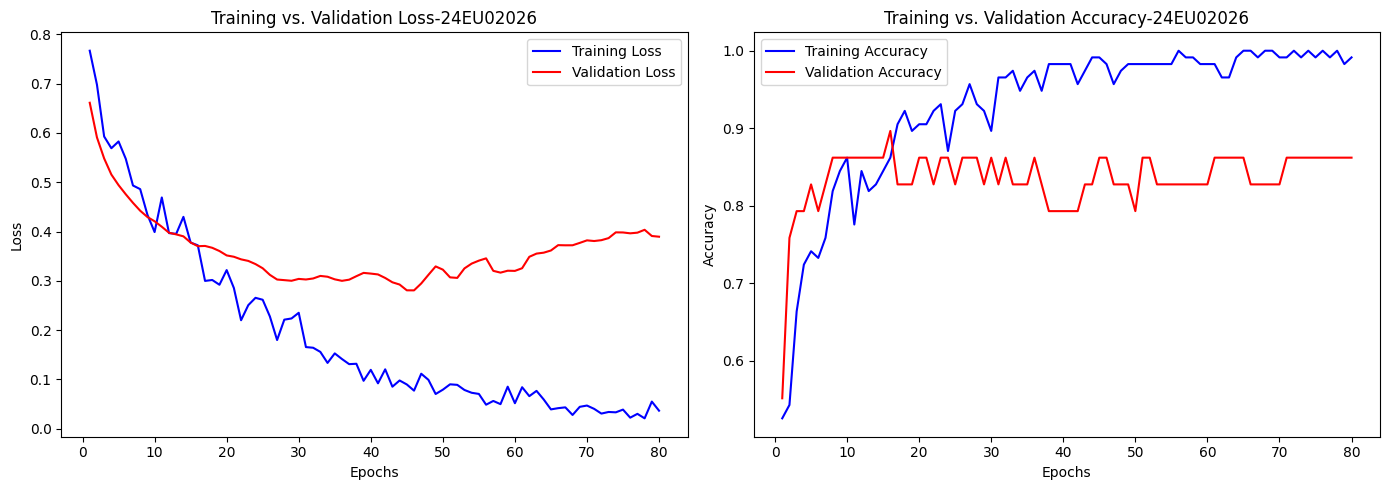

In [10]:
import matplotlib.pyplot as plt

# Extract metrics from training history
train_loss = history_sonar.history['loss']
val_loss = history_sonar.history['val_loss']
train_acc = history_sonar.history['accuracy']
val_acc = history_sonar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[0].set_title("Training vs. Validation Loss-24EU02026")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot accuracy curves
axes[1].plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[1].set_title("Training vs. Validation Accuracy-24EU02026")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
--- Classification Report (Sonar Test Set) ---
              precision    recall  f1-score   support

    Rock (0)       0.79      0.90      0.84        29
    Mine (1)       0.90      0.79      0.84        34

    accuracy                           0.84        63
   macro avg       0.84      0.85      0.84        63
weighted avg       0.85      0.84      0.84        63



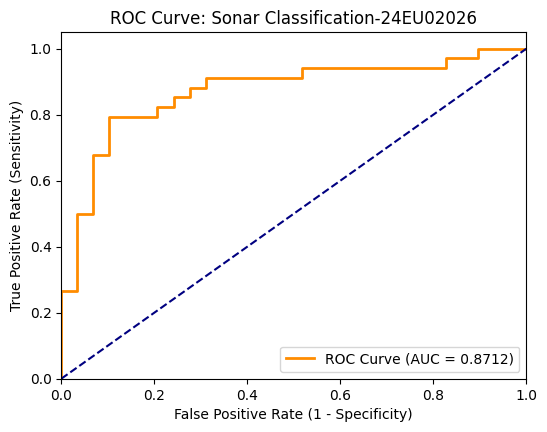

In [12]:
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities on test set
sonar_probs = ann_sonar.predict(X_test_s)[:, 0]
sonar_preds = (sonar_probs >= 0.5).astype(int)

# Print classification report
print("--- Classification Report (Sonar Test Set) ---")
print(classification_report(y_test_s, sonar_preds, target_names=['Rock (0)', 'Mine (1)']))

# Compute ROC curve coordinates and AUC score
fpr, tpr, _ = roc_curve(y_test_s, sonar_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve: Sonar Classification-24EU02026")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define parameterized builder function
def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer_name,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Modular ANN model builder function established.")


Modular ANN model builder function established.


In [14]:
optimizers = ['adam', 'sgd', 'rmsprop']
history_records = {}

print("--- Running Optimizer Search ---")
for opt in optimizers:
    print(f"Training network using: {opt}...")
    temp_model = build_ann_model(optimizer_name=opt)

    # Fit for 30 epochs
    hist = temp_model.fit(
        X_train_p,
        y_train_p,
        validation_split=0.2,
        epochs=30,
        batch_size=16,
        verbose=0
    )
    history_records[opt] = hist.history['loss']

print("Tuning loop complete.")


--- Running Optimizer Search ---
Training network using: adam...
Training network using: sgd...
Training network using: rmsprop...
Tuning loop complete.


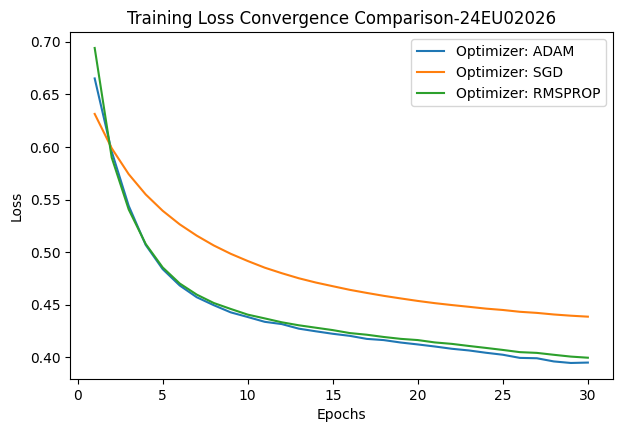

In [16]:
import matplotlib.pyplot as plt

# Plot optimizer training loss profiles
plt.figure(figsize=(7, 4.5))
for opt in optimizers:
    plt.plot(range(1, 31), history_records[opt], label=f"Optimizer: {opt.upper()}")

plt.title("Training Loss Convergence Comparison-24EU02026")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# Configure EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Build model with the optimal optimizer found
tuned_model = build_ann_model(optimizer_name='adam')

print("Training model with Early Stopping...")
# Fit model for up to 100 epochs
history_tuned = tuned_model.fit(
    X_train_p,
    y_train_p,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Training model with Early Stopping...
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6232 - loss: 0.6768 - val_accuracy: 0.6341 - val_loss: 0.6347
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7026 - loss: 0.5780 - val_accuracy: 0.7073 - val_loss: 0.5508
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7189 - loss: 0.5219 - val_accuracy: 0.6992 - val_loss: 0.5035
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7658 - loss: 0.4848 - val_accuracy: 0.7236 - val_loss: 0.4774
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7739 - loss: 0.4633 - val_accuracy: 0.7561 - val_loss: 0.4621
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7760 - loss: 0.4501 - val_accuracy: 0.7805 - val_loss: 0.4543
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7882 - loss: 0.4414 - val_accuracy: 0.7805 - val_loss: 0.4495
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7

In [18]:
from sklearn.metrics import accuracy_score

# Evaluate baseline model from Task 1
baseline_accuracy = ann_pima.evaluate(X_test_p, y_test_p, verbose=0)[1]

# Evaluate the tuned, early-stopped model
tuned_accuracy = tuned_model.evaluate(X_test_p, y_test_p, verbose=0)[1]

comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline ANN (Fixed 50 Epochs)', 'Tuned ANN (with Early Stopping)'],
    'Test Accuracy (%)': [baseline_accuracy * 100, tuned_accuracy * 100],
    'Epochs Trained': [50, len(history_tuned.history['loss'])]
})

print("--- Final Performance Comparison ---")
print(comparison_df.to_string(index=False))


--- Final Performance Comparison ---
            Model Configuration  Test Accuracy (%)  Epochs Trained
 Baseline ANN (Fixed 50 Epochs)          72.077924              50
Tuned ANN (with Early Stopping)          75.324672              31
